# Smartwatch Adoption Prediction — Cleaned Dataset Analysis

This notebook repeats the classification analysis after removing the nine variables explicitly identified as random noise (`RV1`–`RV9`).

It includes model evaluation, coefficient/odds-ratio analysis, standardized predictor strength, Lasso feature selection, and Random Forest feature importance.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

import matplotlib.pyplot as plt


## 2. Load the Data

Upload `SmartWatchData.csv` when prompted.


In [2]:

df = pd.read_csv("SmartWatchData.csv")

print("Data shape:", df.shape)
display(df.head())


Data shape: (120000, 40)


,Adopt,Age,Gender,Recency,Tenure,GymMemberOrNot,Ngyms,Areapopl,DistGym,vhp_across,...,RP1,RP2,RP3,RP4,RP5,RP6,RP7,RP8,RP9,TreatCampaign
0,0,30,1,520.0,687.0,0,1,10594,0.5,278.94,...,0.608404,7.0,-9.0,0.0,6.0,8.0,0.967210,0.527164,0.366331,0
1,1,43,2,47.0,68.0,0,1,42252,0.5,5480.56,...,0.547159,8.0,-4.0,1.0,7.0,7.0,0.508173,0.432336,0.002250,1
2,0,45,1,117.0,194.0,0,2,34651,0.5,355.76,...,0.956831,10.0,1.0,2.0,6.0,5.0,0.873779,0.662206,0.085405,1
3,0,27,0,77.0,134.0,0,2,25002,0.5,2516.22,...,0.220168,5.0,-5.0,2.0,1.0,7.0,0.816313,0.431186,0.974182,1
4,0,39,2,181.0,289.0,1,1,40827,0.5,218.34,...,0.273244,7.0,1.0,1.0,2.0,6.0,0.578035,0.391725,0.195579,0


## 3. Remove Random Noise Variables

`RV1` through `RV9` are identified in the project's variable documentation as random-noise variables.


In [4]:
noise_variables = [
    "RP1", "RP2", "RP3", "RP4", "RP5",
    "RP6", "RP7", "RP8", "RP9"
]

df_clean = df.drop(columns=noise_variables)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Removed variables:", noise_variables)


Original shape: (120000, 40)
Cleaned shape: (120000, 31)
Removed variables: ['RP1', 'RP2', 'RP3', 'RP4', 'RP5', 'RP6', 'RP7', 'RP8', 'RP9']


## 4. Define Features and Target

In [5]:
X = df_clean.drop(columns=["Adopt"])
y = df_clean["Adopt"]

print("Number of predictors:", X.shape[1])
print("Target distribution:")
print(y.value_counts())


Number of predictors: 30
Target distribution:
Adopt
0    63896
1    56104
Name: count, dtype: int64


## 5. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (84000, 30)
Test set shape: (36000, 30)


## 6. Evaluation Helper

In [7]:
def print_classification_metrics(model_name, y_true, y_pred, y_proba):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("\n")


# 7. Logistic Regression — No Regularization

Baseline logistic regression using the cleaned predictors.


In [8]:
lr = LogisticRegression(
    penalty=None, solver="lbfgs", max_iter=3000
)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_lr_proba = lr.predict_proba(X_test)[:, 1]

print_classification_metrics(
    "Logistic Regression (No Penalty)",
    y_test, pred_lr, pred_lr_proba
)


--- Logistic Regression (No Penalty) ---
Accuracy: 0.7446111111111111
Precision: 0.7292719167904903
Recall: 0.725649062629369
F1 Score: 0.7274559791308473
ROC AUC: 0.8225756951264531

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76     19091
           1       0.73      0.73      0.73     16909

    accuracy                           0.74     36000
   macro avg       0.74      0.74      0.74     36000
weighted avg       0.74      0.74      0.74     36000





C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 8. Ridge (L2) Logistic Regression

In [9]:
lr_ridge = LogisticRegression(
    penalty="l2", solver="lbfgs", max_iter=3000
)
lr_ridge.fit(X_train, y_train)

pred_lr_ridge = lr_ridge.predict(X_test)
pred_lr_ridge_proba = lr_ridge.predict_proba(X_test)[:, 1]

print_classification_metrics(
    "Logistic Regression (Ridge - L2)",
    y_test, pred_lr_ridge, pred_lr_ridge_proba
)


--- Logistic Regression (Ridge - L2) ---
Accuracy: 0.7361666666666666
Precision: 0.7274568780308146
Recall: 0.7008693595126856
F1 Score: 0.7139156626506024
ROC AUC: 0.8150047025071138

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.77      0.76     19091
           1       0.73      0.70      0.71     16909

    accuracy                           0.74     36000
   macro avg       0.74      0.73      0.73     36000
weighted avg       0.74      0.74      0.74     36000





C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 9. Standardized Lasso (L1) Logistic Regression

Standardization makes the L1 penalty more comparable across predictors measured on different scales.


In [10]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1", solver="saga",
        max_iter=3000, random_state=42
    ))
])

lasso_pipeline.fit(X_train, y_train)

pred_lr_lasso = lasso_pipeline.predict(X_test)
pred_lr_lasso_proba = lasso_pipeline.predict_proba(X_test)[:, 1]

print_classification_metrics(
    "Logistic Regression (Standardized Lasso - L1)",
    y_test, pred_lr_lasso, pred_lr_lasso_proba
)


--- Logistic Regression (Standardized Lasso - L1) ---
Accuracy: 0.7848888888888889
Precision: 0.7736310981071237
Recall: 0.7662191732213615
F1 Score: 0.7699072973615403
ROC AUC: 0.8699112959483106

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80     19091
           1       0.77      0.77      0.77     16909

    accuracy                           0.78     36000
   macro avg       0.78      0.78      0.78     36000
weighted avg       0.78      0.78      0.78     36000





# 10. Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
pred_rf_proba = rf.predict_proba(X_test)[:, 1]

print_classification_metrics(
    "Random Forest Classifier",
    y_test, pred_rf, pred_rf_proba
)


--- Random Forest Classifier ---
Accuracy: 0.8438611111111111
Precision: 0.8273781902552204
Recall: 0.8435744278195044
F1 Score: 0.8353978154557966
ROC AUC: 0.92773723302922

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85     19091
           1       0.83      0.84      0.84     16909

    accuracy                           0.84     36000
   macro avg       0.84      0.84      0.84     36000
weighted avg       0.84      0.84      0.84     36000





# 11. Compare All Models

In [12]:
metrics_df = pd.DataFrame([
    {
        "Model": "Logistic Regression (No Penalty)",
        "Accuracy": accuracy_score(y_test, pred_lr),
        "Precision": precision_score(y_test, pred_lr),
        "Recall": recall_score(y_test, pred_lr),
        "F1 Score": f1_score(y_test, pred_lr),
        "ROC AUC": roc_auc_score(y_test, pred_lr_proba)
    },
    {
        "Model": "Logistic Regression (Ridge - L2)",
        "Accuracy": accuracy_score(y_test, pred_lr_ridge),
        "Precision": precision_score(y_test, pred_lr_ridge),
        "Recall": recall_score(y_test, pred_lr_ridge),
        "F1 Score": f1_score(y_test, pred_lr_ridge),
        "ROC AUC": roc_auc_score(y_test, pred_lr_ridge_proba)
    },
    {
        "Model": "Logistic Regression (Standardized Lasso - L1)",
        "Accuracy": accuracy_score(y_test, pred_lr_lasso),
        "Precision": precision_score(y_test, pred_lr_lasso),
        "Recall": recall_score(y_test, pred_lr_lasso),
        "F1 Score": f1_score(y_test, pred_lr_lasso),
        "ROC AUC": roc_auc_score(y_test, pred_lr_lasso_proba)
    },
    {
        "Model": "Random Forest Classifier",
        "Accuracy": accuracy_score(y_test, pred_rf),
        "Precision": precision_score(y_test, pred_rf),
        "Recall": recall_score(y_test, pred_rf),
        "F1 Score": f1_score(y_test, pred_rf),
        "ROC AUC": roc_auc_score(y_test, pred_rf_proba)
    }
])

display(metrics_df.sort_values("ROC AUC", ascending=False))


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,Random Forest Classifier,0.843861,0.827378,0.843574,0.835398,0.927737
2,Logistic Regression (Standardized Lasso - L1),0.784889,0.773631,0.766219,0.769907,0.869911
0,Logistic Regression (No Penalty),0.744611,0.729272,0.725649,0.727456,0.822576
1,Logistic Regression (Ridge - L2),0.736167,0.727457,0.700869,0.713916,0.815005


# 12. Logistic Regression Coefficients and Odds Ratios

Positive coefficients indicate higher adoption odds; negative coefficients indicate lower adoption odds.

Odds ratio = `exp(coefficient)`.


In [13]:
coef_table = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": lr.coef_[0]
})

coef_table["Odds_Ratio"] = np.exp(coef_table["Coefficient"])

display(coef_table.sort_values("Coefficient", ascending=False))


,Variable,Coefficient,Odds_Ratio
22,NonSmoker,2.918030e-01,1.338839
1,Gender,1.052205e-01,1.110956
19,BOGOUsed,9.851009e-02,1.103526
23,BMI,3.675367e-02,1.037437
9,nhp_across,1.896147e-02,1.019142
17,OtherHealthDevices,1.432860e-02,1.014432
29,TreatCampaign,1.148814e-02,1.011554
10,nip_across,5.261706e-03,1.005276
24,DoctorFam,4.126194e-03,1.004135
15,nhr_across,3.264652e-03,1.003270


# 13. Strongest Predictors

Raw coefficient magnitudes cannot be fairly compared when variables use different units. We therefore rank predictors using their standardized coefficient:

`standardized coefficient = coefficient × training-set standard deviation`


In [14]:
feature_std = X_train.std()

standardized_table = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": lr.coef_[0],
    "Standardized_Coefficient": lr.coef_[0] * feature_std.values
})

standardized_table["Absolute_Standardized_Coefficient"] = (
    standardized_table["Standardized_Coefficient"].abs()
)
standardized_table["Odds_Ratio"] = np.exp(standardized_table["Coefficient"])

strongest_predictors = standardized_table.sort_values(
    "Absolute_Standardized_Coefficient", ascending=False
).reset_index(drop=True)

print("Top 10 strongest predictors:")
display(strongest_predictors.head(10))


Top 10 strongest predictors:


,Variable,Coefficient,Standardized_Coefficient,Absolute_Standardized_Coefficient,Odds_Ratio
0,Recency,-0.003412,-1.004114,1.004114,0.996594
1,nhp_across,0.018961,0.696937,0.696937,1.019142
2,nip_across,0.005262,0.391679,0.391679,1.005276
3,nhp_online,-0.030420,-0.346834,0.346834,0.970039
4,vhp_across,0.000158,0.310303,0.310303,1.000158
5,BMI,0.036754,0.281941,0.281941,1.037437
6,Age,-0.024799,-0.269668,0.269668,0.975506
7,ADBPM,-0.012220,-0.166304,0.166304,0.987854
8,NonSmoker,0.291803,0.138672,0.138672,1.338839
9,nip_online,-0.005800,-0.128031,0.128031,0.994217


## 14. Strongest Positive and Negative Predictors

In [15]:
print("Top positive predictors:")
display(
    strongest_predictors[
        strongest_predictors["Standardized_Coefficient"] > 0
    ].head(10)
)

print("Top negative predictors:")
display(
    strongest_predictors[
        strongest_predictors["Standardized_Coefficient"] < 0
    ].head(10)
)


Top positive predictors:


,Variable,Coefficient,Standardized_Coefficient,Absolute_Standardized_Coefficient,Odds_Ratio
1,nhp_across,0.018961,0.696937,0.696937,1.019142
2,nip_across,0.005262,0.391679,0.391679,1.005276
4,vhp_across,0.000158,0.310303,0.310303,1.000158
5,BMI,0.036754,0.281941,0.281941,1.037437
8,NonSmoker,0.291803,0.138672,0.138672,1.338839
10,Adfootsteps,0.000037,0.102477,0.102477,1.000037
11,Gender,0.105220,0.066381,0.066381,1.110956
13,Discounts,0.000068,0.046876,0.046876,1.000068
15,BOGOUsed,0.098510,0.045179,0.045179,1.103526
16,Tenure,0.000139,0.044691,0.044691,1.000139


Top negative predictors:


,Variable,Coefficient,Standardized_Coefficient,Absolute_Standardized_Coefficient,Odds_Ratio
0,Recency,-3.412261e-03,-1.004114,1.004114,0.996594
3,nhp_online,-3.041951e-02,-0.346834,0.346834,0.970039
6,Age,-2.479872e-02,-0.269668,0.269668,0.975506
7,ADBPM,-1.222037e-02,-0.166304,0.166304,0.987854
9,nip_online,-5.799849e-03,-0.128031,0.128031,0.994217
12,vhr_across,-3.310662e-04,-0.064393,0.064393,0.999669
14,CardiacRisk,-1.323945e-01,-0.045580,0.045580,0.875995
19,GymMemberOrNot,-4.899470e-02,-0.018070,0.018070,0.952186
20,Areapopl,-8.169345e-07,-0.015608,0.015608,0.999999
22,DistGym,-1.570358e-03,-0.012822,0.012822,0.998431


# 15. Strongest Logistic Regression Predictors — Plot

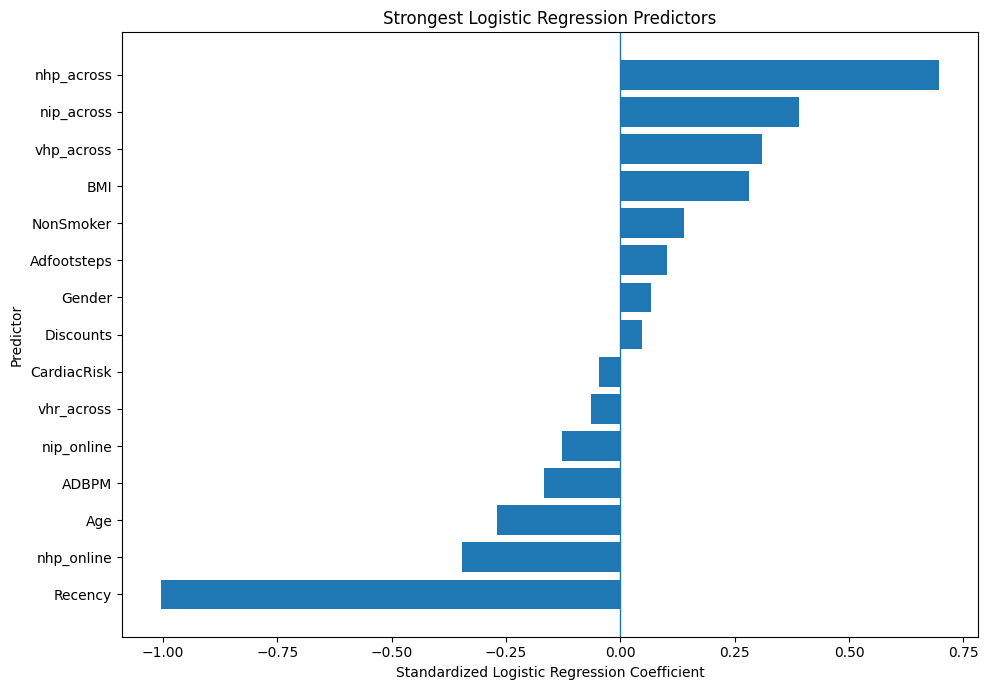

In [16]:
top_plot = strongest_predictors.head(15).sort_values(
    "Standardized_Coefficient"
)

plt.figure(figsize=(10, 7))
plt.barh(top_plot["Variable"], top_plot["Standardized_Coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("Predictor")
plt.title("Strongest Logistic Regression Predictors")
plt.tight_layout()
plt.show()


# 16. Lasso Feature Selection

Lasso can shrink weak predictors to exactly zero. The standardized Lasso model is used here so that variables on different scales are penalized fairly.


In [17]:
lasso_model = lasso_pipeline.named_steps["model"]

lasso_table = pd.DataFrame({
    "Variable": X.columns,
    "Lasso_Coefficient": lasso_model.coef_[0]
})

lasso_table["Selected"] = lasso_table["Lasso_Coefficient"] != 0

print("Number of selected variables:", lasso_table["Selected"].sum())
print("Number of variables removed by Lasso:", (~lasso_table["Selected"]).sum())

display(
    lasso_table.sort_values(
        "Lasso_Coefficient",
        key=lambda s: s.abs(),
        ascending=False
    )
)


Number of selected variables: 30
Number of variables removed by Lasso: 0


,Variable,Lasso_Coefficient,Selected
22,NonSmoker,1.192800,True
2,Recency,-0.721967,True
21,CardiacRisk,-0.603824,True
9,nhp_across,0.578343,True
5,Ngyms,-0.471314,True
8,vhp_across,0.365036,True
19,BOGOUsed,0.363696,True
23,BMI,0.358021,True
27,ADCal,-0.248684,True
7,DistGym,0.246517,True


# 17. Random Forest Feature Importance

Random Forest importance provides a second, nonlinear view of predictor importance.


In [18]:
rf_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Top 15 Random Forest predictors:")
display(rf_importance.head(15))


Top 15 Random Forest predictors:


,Variable,Importance
0,NonSmoker,0.082161
1,DistGym,0.068665
2,nhp_across,0.067987
3,vhp_across,0.065775
4,nip_across,0.061070
5,CardiacRisk,0.059891
6,Recency,0.056082
7,ADCal,0.049333
8,Discounts,0.047391
9,Tenure,0.042613


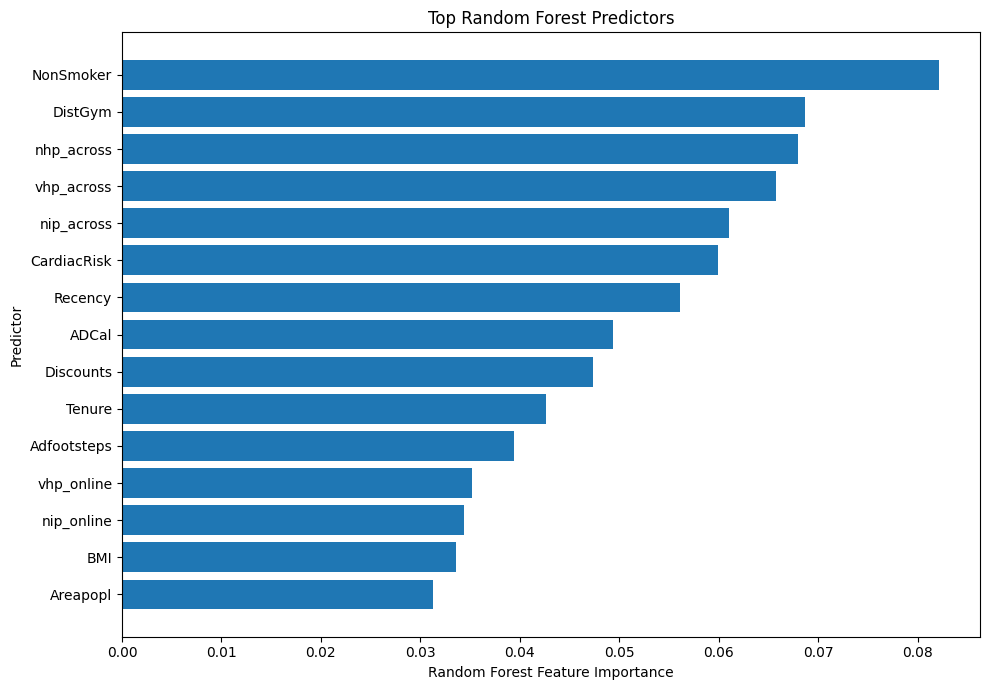

In [19]:
top_rf_plot = rf_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top_rf_plot["Variable"], top_rf_plot["Importance"])
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Predictor")
plt.title("Top Random Forest Predictors")
plt.tight_layout()
plt.show()


# 18. Final Interpretation Guide

- **Model comparison:** use Accuracy, F1 and ROC AUC to compare predictive performance.
- **Logistic coefficient:** gives the direction of association with adoption.
- **Odds ratio:** `exp(coefficient)` gives a more interpretable multiplicative effect on odds.
- **Standardized coefficient:** best for comparing relative predictor strength across differently scaled variables.
- **Lasso:** identifies predictors that can be removed under an L1 penalty.
- **Random Forest importance:** identifies predictors useful for nonlinear prediction.

Important: predictor importance or association does not by itself establish causation.
